### Overview

We cluster the field boundaries extracted in the previous notebook into tight, nearby groups using DBSCAN, then build a grid over each cluster's own extent, capping the size of each cell. This grid will be used in the following notebook to process each cell independently.

### Overview of the Task

We load the field boundaries saved in the previous step and cluster nearby fields together using DBSCAN. For each cluster, we build a grid over its extent, splitting it into cells no larger than a specified size. We use a GeoPandas spatial join on each field's centroid - rather than its full polygon - to assign every field to exactly one grid cell, even when the field's boundary spans more than one cell. We then save the resulting grid and field-to-tile assignments.

### Setup

Determine our runtime environment and connect to Google Drive if needed.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'data'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

Import all required libraries.

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
from shapely.geometry import box
from sklearn.cluster import DBSCAN

### Load Field Boundaries

Load the field boundaries saved by the previous notebook.

In [ ]:
fields_filepath = os.path.join(output_folder, 'field_boundaries.gpkg')
fields_gdf = gpd.read_file(fields_filepath)
fields_gdf

Load the selected Admin2 district boundary saved by the previous notebook, so we can visualize it alongside the grid. Falls back to a default boundary hosted in cloud storage if it isn't found locally.

In [ ]:
admin2_filepath = os.path.join(data_folder, 'selected_admin2.gpkg')
if not os.path.exists(admin2_filepath):
    print(f'Admin2 boundary file not found at {admin2_filepath}.',
          'Using default boundary.')
    admin2_filepath = (
        'https://storage.googleapis.com/spatialthoughts-public-data'
        '/python-remote-sensing/selected_admin2.gpkg')

admin2_gdf = gpd.read_file(admin2_filepath)
admin2_gdf

### Create a Grid

We cluster the fields with DBSCAN and build a grid capped at a maximum cell size over each cluster's extent.

Reproject the field boundaries to the local UTM zone so we can define the grid size in meters.

In [ ]:
utm_crs = fields_gdf.estimate_utm_crs()
fields_proj = fields_gdf.to_crs(utm_crs)
admin2_proj = admin2_gdf.to_crs(utm_crs)

Specify the DBSCAN clustering distance (how close fields must be to join the same cluster) and the maximum size of a grid cell, both in meters.

In [ ]:
TILE_SIZE_M = 10000  # 10 km, max size of a grid cell

# DBSCAN clustering parameters
EPS_M = TILE_SIZE_M * 0.5  # max distance (m) between fields to be in the same cluster
MIN_SAMPLES = 1  # every field joins a cluster (isolated fields form clusters of size 1)

Cluster nearby fields using [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) on their centroid coordinates in the projected CRS. With `min_samples=1`, DBSCAN never labels a field as noise (`-1`) - every field lands in a cluster, including size-1 clusters for isolated fields.

In [ ]:
centroids = np.column_stack([
    fields_proj.geometry.centroid.x,
    fields_proj.geometry.centroid.y,
])

dbscan = DBSCAN(eps=EPS_M, min_samples=MIN_SAMPLES)
fields_proj['cluster_id'] = dbscan.fit_predict(centroids)

print(f'{fields_proj["cluster_id"].nunique()} clusters found')

For each cluster, build a grid over that cluster's own field extent using [`shapely.box`](https://shapely.readthedocs.io/en/stable/reference/shapely.box.html), splitting it into cells no larger than `TILE_SIZE_M`. A cluster whose bounding box already fits within one cell becomes a single tile. Field-to-tile assignment is done in the same loop, using each cluster's own fields and its own grid, so there's no cross-cluster ambiguity.

In [ ]:
tiles = []
tile_ids = []
assignments = {}

for cluster_id, cluster_fields in fields_proj.groupby('cluster_id'):
    minx, miny, maxx, maxy = cluster_fields.total_bounds

    if (maxx - minx) <= TILE_SIZE_M and (maxy - miny) <= TILE_SIZE_M:
        cluster_tiles = [box(minx, miny, maxx, maxy)]
    else:
        xs = np.arange(minx, maxx, TILE_SIZE_M)
        ys = np.arange(miny, maxy, TILE_SIZE_M)
        cluster_union = cluster_fields.union_all()
        cluster_tiles = [
            box(x, y, x + TILE_SIZE_M, y + TILE_SIZE_M)
            for y in ys for x in xs
        ]
        cluster_tiles = [
            tile for tile in cluster_tiles if tile.intersects(cluster_union)
        ]

    cluster_tile_ids = [
        f'tile_{cluster_id:03d}_{i + 1:02d}'
        for i in range(len(cluster_tiles))
    ]

    cluster_grid = gpd.GeoDataFrame(
        {'tile_id': cluster_tile_ids}, geometry=cluster_tiles, crs=utm_crs)

    cluster_centroids = cluster_fields.copy()
    cluster_centroids['geometry'] = cluster_fields.geometry.centroid
    joined = gpd.sjoin(
        cluster_centroids, cluster_grid,
        how='left', predicate='within')
    joined = joined[~joined.index.duplicated(keep='first')]
    assignments.update(joined['tile_id'].to_dict())

    tiles.extend(cluster_tiles)
    tile_ids.extend(cluster_tile_ids)

grid = gpd.GeoDataFrame({'tile_id': tile_ids}, geometry=tiles, crs=utm_crs)
fields_gdf['tile_id'] = fields_proj.index.map(assignments)

print(f'{len(grid)} grid cells created across '
      f'{fields_proj["cluster_id"].nunique()} clusters')

Visualize the grid overlaid on the field boundaries.

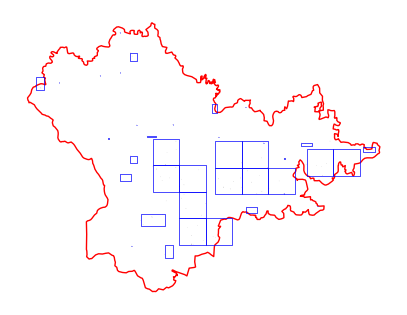

In [22]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5, 5)

admin2_proj.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)
fields_proj.plot(ax=ax, facecolor='#525252', edgecolor='none')
grid.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=0.5)

ax.set_axis_off()
plt.show()

### Save the Results

We save the selected grid cells and the field boundaries as a GeoPackage for use in the next notebook, reprojecting back to EPSG:4326 to match the field boundaries.

In [ ]:
output_filename = 'field_tiling_grid.gpkg'
output_path = os.path.join(output_folder, output_filename)
grid.to_crs('EPSG:4326').to_file(output_path)
print(f'Saved to {output_path}')

In [ ]:
output_filename = 'field_boundaries_with_tile_id.gpkg'
output_path = os.path.join(output_folder, output_filename)
fields_gdf.to_file(output_path)
print(f'Saved to {output_path}')